
## RQ3 — Network Structure and Architectural Influence on Bluesky Science Dissemination

**Research Question:** How does Bluesky’s network structure shape the visibility and flow of scientific information?

---

**Part 1 — Network Construction and Visibility Concentration**

Sub-question: Is scientific attention on Bluesky evenly distributed, or concentrated around a small number of accounts?
Output: Figure 1 — CCDF degree concentration for repost and reply networks
Dataset: `science_posts_unique.parquet` + `engagement/repost_edges.parquet` + `engagement/reply_edges.parquet`
Columns used from `science_posts_unique.parquet`: `post_uri`, `user_did`, `author_handle`
Columns used from `repost_edges.parquet`: `source_post_uri`, `actor_did`, `actor_handle`
Columns used from `reply_edges.parquet`: `source_post_uri`, `did`, `reply_parent_uri`, `reply_root_uri`, `reply_depth`, `reply_path_uris`
Network construction:

* Repost network: `reposter → original science-post author`
* Reply network: `reply author → original science-post author`
  Metrics: in-degree distribution, CCDF, Gini coefficient, top 1% share
  Interpretation: This part measures whether visibility and attention are concentrated among a small number of users.

---

**Important note:**
RQ3 uses engagement edge data, not only post-level engagement counts. `science_posts_unique.parquet` provides the original OpenAlex-validated science-post authors, while `repost_edges.parquet` and `reply_edges.parquet` provide the users who reposted or replied to those posts. Therefore, RQ3 analyzes user-to-user interaction structure rather than only counting likes, reposts, or replies.

The current RQ3 network construction focuses on user-level interaction networks. Nodes represent users, and edges represent repost or reply interactions around OpenAlex-validated science posts. Feed generators are not included because historical feed-indexing data for the March–June 2025 observation window was not collected. Although current feed-generator data could be collected as a snapshot, it would not reliably show which posts were indexed by which feeds during the original study period.

**References:**

* Bik & Goldstein (2013). *PLOS Biology* 11(4): e1001535.
* Blondel et al. (2008). Louvain method. *Journal of Statistical Mechanics*.
* Clauset, Shalizi & Newman (2009). *SIAM Review* 51(4): 661–703.
* Haustein, Costas & Lariviere (2015). *PLOS ONE* 10(3): e0120495.
* Newman (2006). Modularity and community structure. *PNAS* 103(23): 8577–8582.
* Vosoughi, Roy & Aral (2018). *Science* 359(6380): 1146–1151.


## 0. Setup

In [1]:
import warnings, re, subprocess, sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings('ignore')

BASE         = Path('D:/sciencebluesky/final_dataset')
POSTS        = BASE / 'science_posts_unique.parquet'
LIKE_EDGES   = BASE / 'engagement/like_edges.parquet'
REPOST_EDGES = BASE / 'engagement/repost_edges.parquet'
REPLY_EDGES  = BASE / 'engagement/reply_edges.parquet'
OUTPUT_DIR   = Path('D:/sciencebluesky/analysis/RQ3')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START = '2025-03-01'
END   = '2025-06-30'

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
})

INST_COLOR  = '#C06B4F'
INDIV_COLOR = '#2E86AB'

def fmt_k(x, _=None):
    if x >= 1_000_000: return f'{x/1e6:.1f}M'
    if x >= 1_000:     return f'{x/1e3:.0f}K'
    return f'{int(x)}'

def save_fig(name):
    for ext in ['pdf', 'png']:
        plt.savefig(OUTPUT_DIR / f'{name}.{ext}',
                    dpi=300 if ext=='png' else None, bbox_inches='tight')
    print(f'Saved: {name}.pdf / .png')

print('Setup complete.')

Setup complete.


## 1. Data Loading

In [2]:
posts = pd.read_parquet(POSTS)
posts['created_at'] = pd.to_datetime(posts['created_at'], errors='coerce', utc=True)
if 'openalex_found' in posts.columns:
    posts = posts[posts['openalex_found'] == True].copy()
posts = posts[
    (posts['created_at'] >= pd.Timestamp(START, tz='UTC')) &
    (posts['created_at'] <= pd.Timestamp(END, tz='UTC') + pd.Timedelta(days=1))
].drop_duplicates('post_uri').reset_index(drop=True)

likes   = pd.read_parquet(LIKE_EDGES)   if LIKE_EDGES.exists()   else pd.DataFrame()
reposts = pd.read_parquet(REPOST_EDGES) if REPOST_EDGES.exists() else pd.DataFrame()
replies = pd.read_parquet(REPLY_EDGES)  if REPLY_EDGES.exists()  else pd.DataFrame()

# Institutional classifier — high-confidence patterns only
INSTITUTIONAL_PATTERNS = [
    r'\.edu$', r'\.edu\.', r'\.ac\.',
    r'\.nih\.gov', r'\.nasa\.gov', r'\.who\.int', r'\.cdc\.gov',
    r'nature\.com', r'nejm\.org', r'thelancet\.com',
    r'biorxiv\.org', r'medrxiv\.org', r'arxiv\.org',
    r'mit\.edu', r'harvard\.edu', r'stanford\.edu',
    r'cern\.ch', r'\.ieee\.org', r'\.acm\.org',
]

def is_institutional(handle):
    if not isinstance(handle, str): return False
    return any(re.search(p, handle.lower()) for p in INSTITUTIONAL_PATTERNS)

handle_col = next((c for c in ['author_handle','handle','user_handle']
                   if c in posts.columns), None)
if handle_col:
    posts['is_institutional'] = posts[handle_col].map(is_institutional)

print(f'Posts:          {len(posts):,}')
print(f'Like edges:     {len(likes):,}')
print(f'Repost edges:   {len(reposts):,}')
print(f'Reply edges:    {len(replies):,}')
print(f'Unique authors: {posts["user_did"].nunique():,}')
if handle_col:
    n_inst = posts['is_institutional'].sum()
    print(f'Institutional posts: {n_inst:,} ({n_inst/len(posts)*100:.1f}%)')

Posts:          115,789
Like edges:     555,582
Repost edges:   174,867
Reply edges:    53,893
Unique authors: 29,971
Institutional posts: 717 (0.6%)


---
## Part 1 — Network Construction

**Question:** What is the scale and structure of the science interaction network on Bluesky?

**Method:** Weighted directed user-to-user graph. Each edge = one user interacting with
another user's post. Repost and reply networks are kept separate — reposts measure
amplification, replies measure discussion.

**Figure 1** answers: Is scientific visibility concentrated in a few accounts?
The CCDF shows the degree distribution — a steep power-law tail means a small number of
accounts capture most of the reposts (Clauset et al. 2009; Vosoughi et al. 2018).
Gini coefficient summarises this inequality in one number.

**Reference:** Clauset, Shalizi & Newman (2009, *SIAM Review* 51(4):661-703).

### 1.1 Network Libraries + Build Graphs

In [3]:
for pkg in ['networkx', 'python-louvain']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import networkx as nx
try:
    import community as community_louvain
    LOUVAIN_AVAILABLE = True
except ImportError:
    LOUVAIN_AVAILABLE = False

print(f'NetworkX: {nx.__version__} | Louvain: {LOUVAIN_AVAILABLE}')

post_author = posts.set_index('post_uri')['user_did'].to_dict()
post_handle = {}
if handle_col and 'user_did' in posts.columns:
    post_handle = posts.drop_duplicates('user_did').set_index('user_did')[handle_col].to_dict()

def build_user_edges(edge_df, actor_col, post_uri_col, edge_type):
    if edge_df.empty or post_uri_col not in edge_df.columns:
        return pd.DataFrame(columns=['source','target','edge_type'])
    df = edge_df[[actor_col, post_uri_col]].copy()
    df['target'] = df[post_uri_col].map(post_author)
    df = df.dropna(subset=['target'])
    df = df[df[actor_col] != df['target']]
    df['edge_type'] = edge_type
    return df.rename(columns={actor_col:'source'})[['source','target','edge_type']]

def build_weighted_digraph(edge_df, edge_type_filter=None):
    G = nx.DiGraph()
    if edge_df.empty: return G
    subset = edge_df if edge_type_filter is None else edge_df[edge_df['edge_type']==edge_type_filter]
    w = subset.groupby(['source','target']).size().reset_index(name='weight')
    for _, row in w.iterrows():
        G.add_edge(row['source'], row['target'], weight=int(row['weight']))
    return G

repost_edges = build_user_edges(reposts, 'actor_did', 'source_post_uri', 'repost')
reply_author_col = next((c for c in ['reply_author_did','did'] if c in replies.columns), None)
reply_edges = (build_user_edges(replies, reply_author_col, 'source_post_uri', 'reply')
               if reply_author_col else pd.DataFrame(columns=['source','target','edge_type']))

all_edges_df = pd.concat([repost_edges, reply_edges], ignore_index=True)
G_repost = build_weighted_digraph(all_edges_df, 'repost')
G_reply  = build_weighted_digraph(all_edges_df, 'reply')

# Network summary table
def network_stats(G, name):
    n, e = G.number_of_nodes(), G.number_of_edges()
    if n == 0: return {}
    in_deg  = [d for _, d in G.in_degree()]
    wccs    = list(nx.weakly_connected_components(G))
    lcc_pct = max(len(c) for c in wccs) / n * 100 if wccs else 0
    return {'Network': name, 'Nodes': n, 'Edges': e,
            'Density': round(nx.density(G), 6),
            'Mean in-degree': round(np.mean(in_deg), 2),
            'Max in-degree': max(in_deg),
            'LCC%': round(lcc_pct, 1),
            'Reciprocity': round(nx.reciprocity(G), 4)}

summary_df = pd.DataFrame([network_stats(G_repost,'Repost'), network_stats(G_reply,'Reply')])
summary_df.to_csv(OUTPUT_DIR/'table1_network_summary.csv', index=False, encoding='utf-8-sig')
print(summary_df.to_string(index=False))

NetworkX: 3.2.1 | Louvain: True
Network  Nodes  Edges  Density  Mean in-degree  Max in-degree  LCC%  Reciprocity
 Repost  77925 143205 0.000024            1.84           3111  93.9       0.0161
  Reply  19503  18496 0.000049            0.95            643  64.5       0.0042


### 1.2 Figure 1 — Degree Distribution (CCDF)

Repost Network: Gini=0.706 | Top-1% share=28.3%
Reply Network: Gini=0.577 | Top-1% share=26.2%
Saved: fig1_network_ccdf.pdf / .png


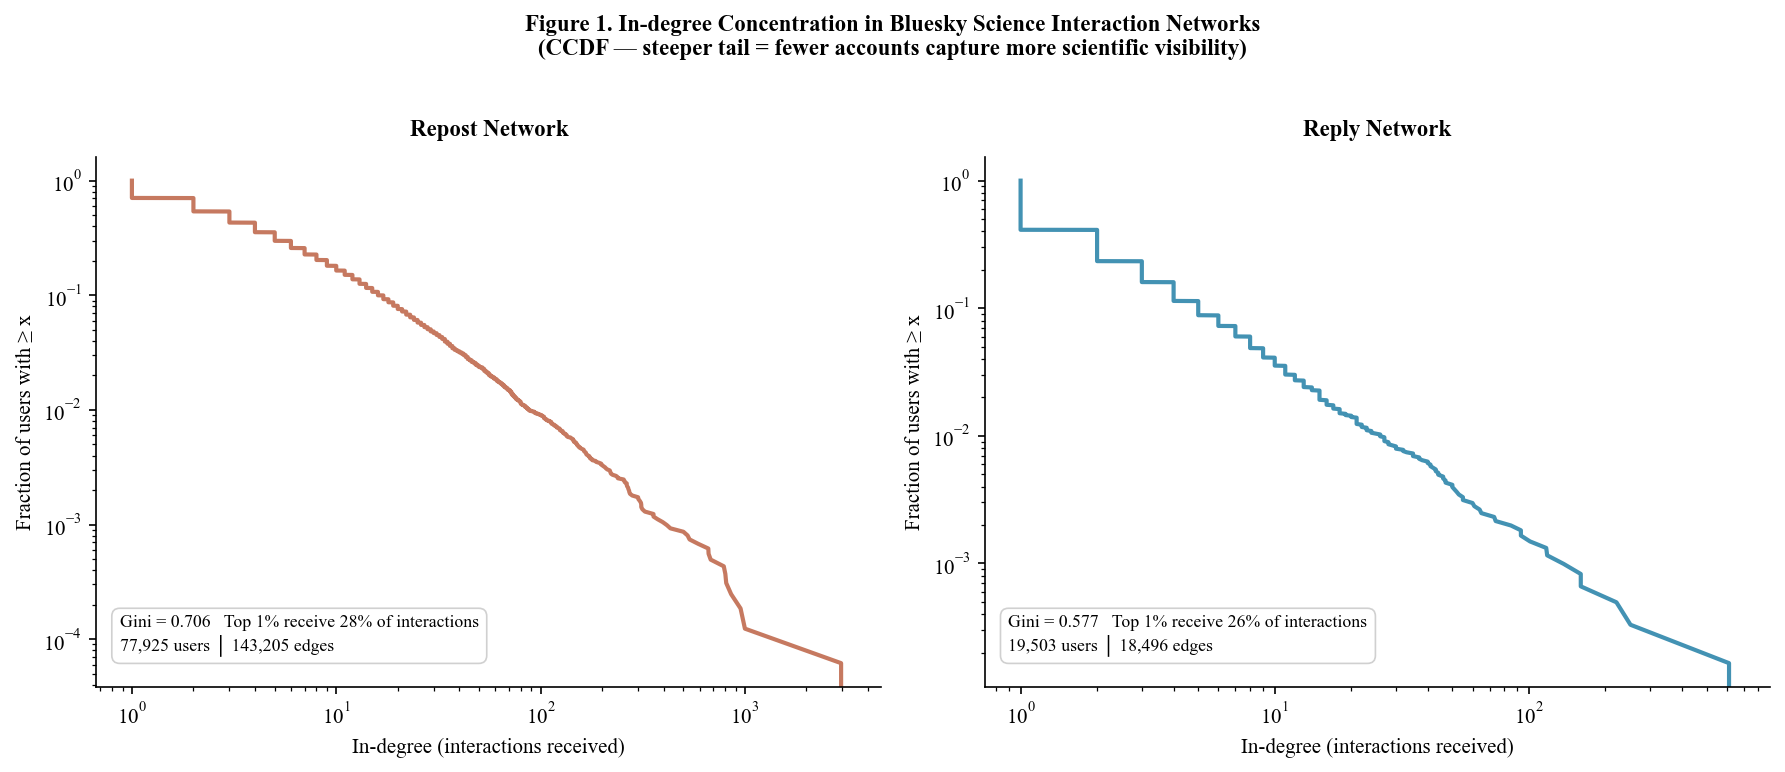

In [10]:
# CCDF is the correct visualisation for power-law assessment (Clauset et al. 2009)
# Gini coefficient quantifies inequality: 0 = perfect equality, 1 = one account gets all
# NOTE: correct Gini formula for sorted array (ascending)

def compute_gini(arr):
    arr = np.sort(arr.astype(float))
    n   = len(arr)
    if n == 0 or arr.sum() == 0: return 0
    index = np.arange(1, n+1)
    return (2 * np.sum(index * arr) - (n+1) * arr.sum()) / (n * arr.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

network_pairs = [
    (G_repost, 'Repost Network', INST_COLOR),
    (G_reply,  'Reply Network',  INDIV_COLOR),
]

for ax, (G, title, color) in zip(axes, network_pairs):
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    in_deg     = np.array([d for _, d in G.in_degree() if d > 0])
    sorted_deg = np.sort(in_deg)
    ccdf       = 1 - np.arange(1, len(sorted_deg)+1) / len(sorted_deg)

    ax.plot(sorted_deg, ccdf, color=color, linewidth=2, alpha=0.9)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('In-degree (interactions received)', fontsize=10)
    ax.set_ylabel('Fraction of users with ≥ x', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

    gini        = compute_gini(in_deg)
    top1_thresh = np.percentile(in_deg, 99)
    top1_share  = in_deg[in_deg >= top1_thresh].sum() / in_deg.sum() * 100

    # Annotation at BOTTOM-LEFT — avoids overlapping the power-law tail
    ax.text(0.03, 0.06,
        f'Gini = {gini:.3f}   Top 1% receive {top1_share:.0f}% of interactions\n'
        f'{G.number_of_nodes():,} users │ {G.number_of_edges():,} edges',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
                  alpha=0.92, edgecolor='#cccccc', linewidth=0.8))

    print(f'{title}: Gini={gini:.3f} | Top-1% share={top1_share:.1f}%')

fig.suptitle(
    'Figure 1. In-degree Concentration in Bluesky Science Interaction Networks\n'
    '(CCDF — steeper tail = fewer accounts capture more scientific visibility)',
    fontsize=11, fontweight='bold', y=1.02)

plt.tight_layout()
save_fig('fig1_network_ccdf')

### How Figure 1 works — Repost and Reply Network Concentration

**Figure 1 specifically:**

Figure 1 analyzes the structure of repost and reply networks in Bluesky science communication. Unlike RQ2, which mainly uses post-level engagement counts, this part uses **engagement edge data** to build user-to-user networks.

The figure uses three main datasets:

* `science_posts_unique.parquet` — provides the original OpenAlex-validated science posts and their authors
* `engagement/repost_edges.parquet` — provides users who reposted each science post
* `engagement/reply_edges.parquet` — provides users who replied under each science post

---

**Repost network:**

The repost network represents science dissemination or amplification.

```text
Repost network edge:
reposter → original science-post author
```

For example, if User A reposts a science post written by User B, the network creates an edge:

```text
User A → User B
```

This means User A helped spread User B’s science post.

In this network, a user with high **in-degree** is an account whose science posts were reposted by many other users. Therefore, high in-degree in the repost network means high dissemination visibility.

---

**Reply network:**

The reply network represents discussion attention.

```text
Reply network edge:
reply author → original science-post author
```

For example, if User C replies under a science post written by User B, the network creates an edge:

```text
User C → User B
```

This means User C participated in discussion around User B’s science post.

In this network, a user with high **in-degree** is an account whose science posts attracted replies from many users. Therefore, high in-degree in the reply network means high discussion attention.

Important note: this reply network does not fully represent every reply-to-reply conversation path. It mainly measures which original science-post authors attracted discussion. The detailed reply tree is stored in `reply_edges.parquet` through fields such as `reply_parent_uri`, `reply_root_uri`, `reply_depth`, and `reply_path_uris`.

---

**How to read Figure 1:**

Figure 1 uses a CCDF degree concentration plot.

```text
X-axis = in-degree
Y-axis = probability of accounts having at least that in-degree
```

In simple terms:

```text
X-axis = how many users reposted or replied to an account
Y-axis = how many accounts reached that level or higher
```

If the curve drops quickly, it means most accounts receive only a small number of reposts or replies. If the curve extends far to the right, it means a small number of accounts receive very high attention.

This pattern is called a **heavy-tailed distribution**. It means attention is not evenly distributed.

---

**What the output means:**

The repost network is larger and more concentrated than the reply network.

```text
Repost network:
Nodes: 77,925
Edges: 143,205
Gini: 0.706
Top 1% share: 28.3%
```

This means repost-based dissemination is highly unequal. A small group of accounts receives a large share of repost attention.

```text
Reply network:
Nodes: 19,503
Edges: 18,496
Gini: 0.577
Top 1% share: 26.2%
```

This means discussion attention is also concentrated, but the reply network is smaller and less unequal than the repost network.

Overall, Figure 1 shows that science visibility on Bluesky is structurally concentrated. Most science-posting accounts receive limited repost or reply attention, while a small number of accounts receive disproportionately high amplification and discussion.
